Inputs shape: (48, 8)
Outputs shape: (48,)
First 20 rows of raw data:
    hype-para-1  hype-para-2  hype-para-3  hype-para-4  hype-para-5  hype-para-6  hype-para-7  hype-para-8    output  source
41     0.121212     0.121212     0.000000     0.000000     0.363636     0.727273     0.484849     0.848484  9.609759  week-2
14     0.056447     0.065956     0.022929     0.038786     0.403935     0.801055     0.488307     0.893085  9.598482    file
47     0.045306     0.045319     0.045319     0.033695     0.337741     0.771663     0.496881     0.775992  9.588003  week-8
42     0.043751     0.045306     0.045319     0.033695     0.337741     0.771663     0.496881     0.775992  9.587655  week-3
45     0.010000     0.661416     0.010000     0.212650     0.889104     0.671374     0.010000     0.450308  9.567349  week-6
40     0.000000     0.125000     0.000000     0.000000     0.375000     0.750000     0.500000     0.875000  9.565800  week-1
46     0.138474     0.190151     0.378834     0.303465 

/Users/ajay.amrite/Documents/AI Course/Capstone/Black-Box functions/data/BaseDataHandler.py:134: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_copy = pd.concat([df, new_df], ignore_index=True)


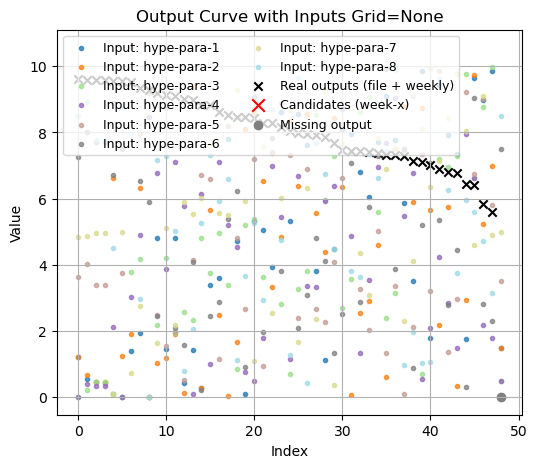

Saved LLM candidates to: results/run_2025-12-22 12-03-37/df_llm_candidates.csv

Pipeline finished.
Pipeline finished. Results keys: ['llm']


In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (6, 5)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh)

print("Pipeline finished. Results keys:", list(results.keys()))